In [ ]:
import math
import cv2
import numpy as np
import gymnasium as gym

from time import sleep
from gymnasium import spaces


n_frames = 1_800 # number of video frames
n = 4 # number of tiles per row/column
num_tiles = n*n # total number of tiles

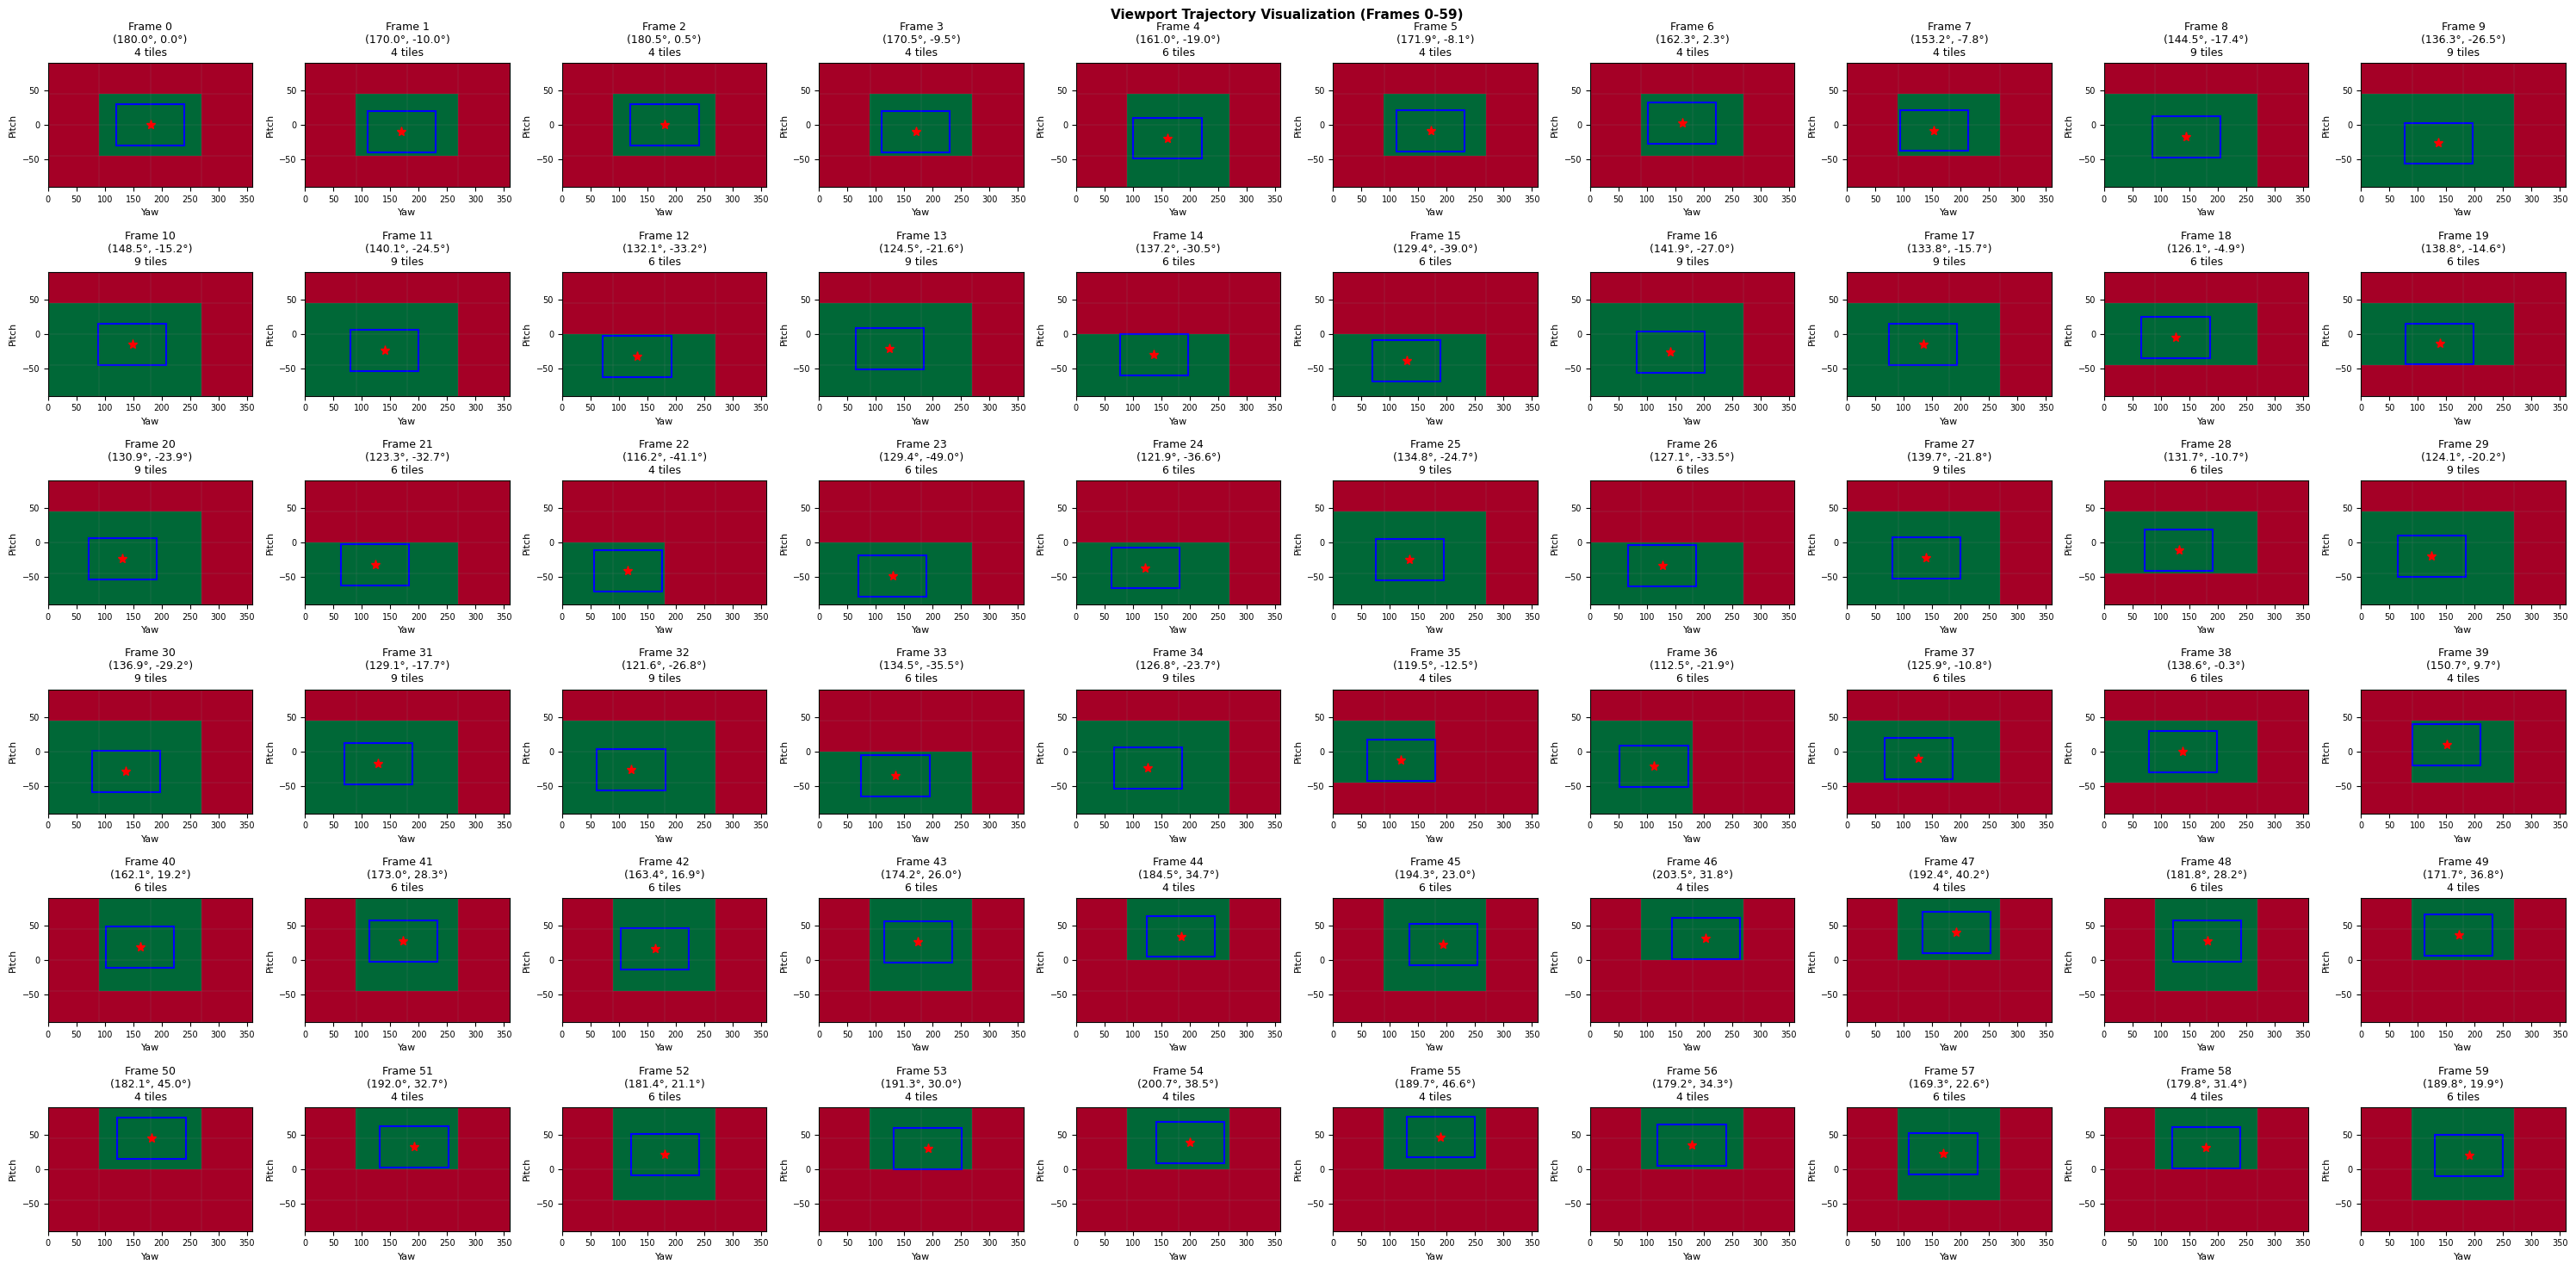

In [39]:
from importnb import Notebook
with Notebook():
    from LabTrajectory import simulate_viewport_with_tiles, visualize_trajectory_sequence

if __name__ == "__main__":
    yaw, pitch, tiles_per_frame, tiles_array = simulate_viewport_with_tiles(
        num_steps=n_frames,
        n=n,
        fov_yaw=120,
        fov_pitch=60,
        damping=0.95,
        step_size=10,
        start_yaw=180,
        start_pitch=0
    )

    window_len = 60
    n_users = len(tiles_per_frame) // window_len  # use all available non-overlapping segments

    user_tiles = []
    for u in range(n_users):
        start = u * window_len
        end = start + window_len
        user_tiles.append({
            "tiles": tiles_per_frame[start:end],
            "yaw": yaw[start:end],
            "pitch": pitch[start:end],
        })

    if n_users >= 1:
        user_tiles_1 = user_tiles[0]["tiles"]
        yaw_1 = user_tiles[0]["yaw"]
        pitch_1 = user_tiles[0]["pitch"]

    if n_users >= 2:
        user_tiles_2 = user_tiles[1]["tiles"]
        yaw_2 = user_tiles[1]["yaw"]
        pitch_2 = user_tiles[1]["pitch"]

    visualize_trajectory_sequence(
        yaw_1, 
        pitch_1, 
        user_tiles_1, 
        n=n, 
        fov_yaw=120, 
        fov_pitch=60,
        start_frame=0, 
        num_frames_to_show=60, 
        cols=10
    )

In [ ]:
def zipf(samples = None, total_videos = 10, alpha = 1.0):
    zipf_dist = [1.0 / (i ** alpha) for i in range(1, total_videos + 1)]
    zipf_dist = [x / sum(zipf_dist) for x in zipf_dist]

    indices = np.random.choice(total_videos, samples, p=zipf_dist)
    data = np.random.permutation(np.arange(1, total_videos + 1))

    elements = [int(data[i]) for i in indices]

    return elements
videos_requests_idx = zipf(n_users)

In [ ]:
# CPT parameters (typical values from literature; adjustable)
alpha = 0.88  # gain curvature
beta = 0.88   # loss curvature
lam = 2.25    # loss aversion (losses weighted more)
prelec_gamma = 0.65  # probability weighting parameter (Prelec)

class CPTPrefetchEnvSimple(gym.Env):
    def __init__(
        self, 
        num_tiles: int = num_tiles,
        n_users: int = 1,
        cache_capacity: int = 10,
        user_tiles: np.ndarray = None,
        videos_requests: list = None,
    ):
        super(CPTPrefetchEnvSimple, self).__init__()

        self.capacity = self.cache_capacity = cache_capacity
        self.sizes = np.random.randint(1, 4, size=num_tiles) 

        self.gain_if_prefetched = 1.0
        self.loss_if_not_prefetched = -1.0

        self.theta = 0.65
        self.gamma = 0.7
        self.alpha = 0.88
        self.beta = 0.88
        self.lam = 2.25

        self.step_count = 0
        self.n_users = n_users
        self.num_tiles = num_tiles
        self.user_tiles = user_tiles if user_tiles is not None else []
        self.videos_requests = videos_requests if videos_requests is not None else []

    def reset(self):
        self.state = np.zeros(num_tiles, dtype=float)
        return self.state

    def step(self, action):
        self.state = np.random.rand(4)
        info       = {}
        reward     = 0.0

        by_video = {}
        for user_action in action:
            vid = user_action.get('video', None)
            tiles = user_action.get('tiles', None)

            if vid not in by_video:
                by_video[vid] = np.zeros(self.num_tiles, dtype=int)
            
            by_video[vid] += (tiles > 0)

        info['videos_considered'] = list(by_video.keys())

        video_tile_counts = []
        for vid, arr in by_video.items():
            for tile_idx, count in enumerate(arr):
                video_tile_counts.append((vid, tile_idx, count))

        # Sort by count descending
        video_tile_counts_sorted = sorted(video_tile_counts, key=lambda x: x[2], reverse=True)

        n_prefetch = len(video_tile_counts_sorted)
        if n_prefetch > self.capacity:
            to_drop = int(n_prefetch - self.capacity)
            dropped = video_tile_counts_sorted[-to_drop:]

            for vid, tile_idx, count in dropped:
                by_video[vid][tile_idx] = 0

            info['global_clipped_dropped'] = [
                {'video': vid, 'tile_index': tile_idx} for vid, tile_idx, count in dropped
            ]

        current_p = {}
        total_requests = sum(count for _, _, count in video_tile_counts_sorted)
        if total_requests == 0:
            total_requests = 1  # avoid division by zero

        for vid, tile_idx, count in video_tile_counts_sorted:
            current_p[(vid, tile_idx)] = count / total_requests

        # print("Current probabilities:", current_p)
        

        requests = self.videos_tiles_requested(self.step_count)

    
        # compute reward for this video's action and add
        reward += self.compute_expected_cpt_reward(
            action=by_video,
            current_p=current_p,
            video_tile_counts_sorted=video_tile_counts_sorted,
            requests=requests
        )
    
        return self.state, float(reward), False, info

    def compute_expected_cpt_reward(self, action, current_p, video_tile_counts_sorted, requests) -> float:
        expected_reward = 0.0

        for vid, arr in action.items():
            for tile_idx, act in enumerate(arr):
                tile_key = (vid, tile_idx)
                p = float(current_p.get(tile_key, 0.0))
                w = self.prelec_w(p, theta=self.theta)
                if act == 1:
                    expected_outcome = p * self.gain_if_prefetched
                else:
                    expected_outcome = p * self.loss_if_not_prefetched
                
                v = self.cpt_value(expected_outcome, alpha=self.alpha, beta=self.beta, lam=self.lam)
                expected_reward += w * v

        return float(expected_reward)

    def prelec_w(self, p: float, theta: float = 0.65) -> float:
        if p <= 0.0: return 0.0
        if p >= 1.0: return 1.0
        return math.exp(-((-math.log(p)) ** theta))

    def cpt_value(
        self,
        x: float, 
        alpha: float = 0.88, 
        beta: float = None, 
        lam: float = 2.25, 
        x0: float = 0.0
    ) -> float:
        if beta is None:
            beta = alpha
        diff = x - x0
        if diff >= 0:
            return diff ** alpha
        else:
            return -lam * ((-diff) ** beta)

    def videos_tiles_requested(self, step) -> np.ndarray:
        requests = [
            {
                'user': i,
                'video': self.videos_requests[i],
                'tiles': self.user_tiles[i]['tiles'][step]
            } for i in range(self.n_users)
        ]
        return requests


In [ ]:
def tiles_to_action_mapping(obs, step, i) -> np.ndarray:
    action = np.zeros(num_tiles, dtype=int)
    
    if step < 0: return action
    
    for tile in user_tiles[i]['tiles'][step]:
        tx, ty = tile[0] - 1, tile[1] - 1
        action[tx + ty*n] = 1
    return action

In [ ]:
window_len = 60
n_users = len(tiles_per_frame) // window_len  # use all available non-overlapping segments

def run_episodes(n_episodes=100, max_steps=60, capacity=50):
    episode_rewards = []
    episode_lengths = []
    
    for ep in range(n_episodes):
        # Compute user tiles again for each episode to introduce variability
        yaw, pitch, tiles_per_frame, tiles_array = simulate_viewport_with_tiles(
            num_steps=n_frames,
            n=n,
            fov_yaw=120,
            fov_pitch=60,
            damping=0.95,
            step_size=5.,
            start_yaw=180,
            start_pitch=0
        )

        # Prepare user tiles for each user based on the window length
        user_tiles = [
            {
                "tiles": tiles_per_frame[start:(start + window_len)],
                "yaw": yaw[start:(start + window_len)],
                "pitch": pitch[start:(start + window_len)],
            } for start in range(0, n_users * window_len, window_len)
        ]

        # Generate video requests for users
        videos_requests_idx = zipf(n_users, total_videos = 10, alpha = 2.0)

        env = CPTPrefetchEnvSimple(
            num_tiles=num_tiles,
            n_users=n_users,
            cache_capacity=capacity,
            user_tiles=user_tiles,
            videos_requests=videos_requests_idx 
        )

        obs = env.reset()
        total_reward = 0.0

        for step in range(max_steps):
            actions = [
                {
                    'user': i,
                    'video': videos_requests_idx[i],
                    'tiles': tiles_to_action_mapping(obs, step-1, i)
                } for i in range(n_users)
            ]

            obs, reward, _, info = env.step(actions)
            total_reward += float(reward)

        episode_lengths.append(max_steps)
        episode_rewards.append(total_reward)

    stats = {
        "n_episodes": n_episodes,
        "mean_steps": float(np.mean(episode_lengths)),
        "std_steps": float(np.std(episode_lengths)),
        "mean_reward": float(np.mean(episode_rewards)),
        "std_reward": float(np.std(episode_rewards)),
        "episode_lengths": episode_lengths,
        "episode_rewards": episode_rewards,
    }
    print(f"Episodes: {n_episodes}  Mean steps: {stats['mean_steps']:.2f}  Mean reward: {stats['mean_reward']:.4f}")

    return stats

if __name__ == '__main__':
    capacities = [50, 60, 70, 80, 90, 100, 150, 200, 300]

    capacity_results = {}
    for capacity in capacities:
        results = run_episodes(n_episodes=200, max_steps=60, capacity=capacity)

        capacity_results[capacity] = results

        print(f"Capacity: {capacity}  Mean steps: {results['mean_steps']:.2f}  Mean reward: {results['mean_reward']:.4f}")

        lengths = np.array(results["episode_lengths"])
        rewards = np.array(results["episode_rewards"]) Sources/Examples/LabSimpleEnv.ipynb
        n_eps = len(lengths)

[{'user': 0, 'video': 4, 'tiles': {(1, 1), (1, 2), (2, 1), (2, 2)}}, {'user': 1, 'video': 4, 'tiles': {(1, 2), (2, 1), (1, 1), (2, 0), (2, 2), (1, 0)}}, {'user': 2, 'video': 3, 'tiles': {(1, 1), (1, 2), (2, 1), (2, 2)}}, {'user': 3, 'video': 3, 'tiles': {(1, 1), (1, 2), (2, 1), (2, 2)}}, {'user': 4, 'video': 4, 'tiles': {(1, 1), (1, 2), (2, 1), (2, 2)}}, {'user': 5, 'video': 9, 'tiles': {(1, 1), (1, 2), (2, 1), (2, 2)}}, {'user': 6, 'video': 4, 'tiles': {(1, 2), (2, 1), (1, 1), (2, 0), (2, 2), (1, 0)}}, {'user': 7, 'video': 4, 'tiles': {(1, 2), (2, 1), (1, 1), (2, 0), (2, 2), (1, 0)}}, {'user': 8, 'video': 9, 'tiles': {(1, 1), (1, 2), (2, 1), (2, 2)}}, {'user': 9, 'video': 4, 'tiles': {(1, 0), (1, 1), (2, 0), (2, 1)}}, {'user': 10, 'video': 3, 'tiles': {(1, 2), (2, 1), (1, 1), (2, 0), (2, 2), (1, 0)}}, {'user': 11, 'video': 9, 'tiles': {(1, 1), (1, 2), (2, 1), (2, 2)}}, {'user': 12, 'video': 3, 'tiles': {(1, 2), (2, 1), (1, 1), (2, 3), (2, 2), (1, 3)}}, {'user': 13, 'video': 4, 'tiles'

TypeError: CPTPrefetchEnvSimple.compute_expected_cpt_reward() got an unexpected keyword argument 'video_tile_counts_sorted'

C:\Users\es25591\AppData\Local\Temp\ipykernel_22560\113768884.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[3].boxplot([lengths, rewards], labels=["steps", "reward"])


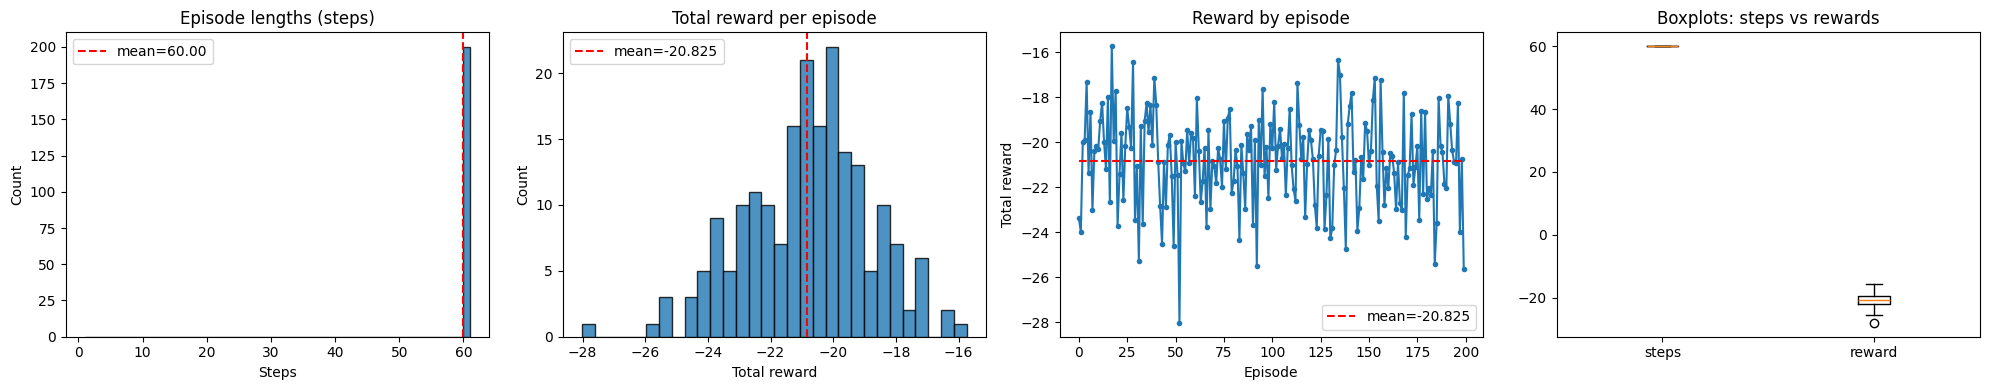

Mean steps: 60.00 ± 0.00
Mean reward: -20.8249 ± 2.0273


In [44]:
##### Print graphs from cell above #####

if __name__ == '__main__':
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # Episode lengths histogram
    axes[0].hist(lengths, bins=range(1, int(lengths.max())+2), alpha=0.8, edgecolor='k')
    axes[0].axvline(lengths.mean(), color='r', linestyle='--', label=f"mean={lengths.mean():.2f}")
    axes[0].set_title("Episode lengths (steps)")
    axes[0].set_xlabel("Steps"); axes[0].set_ylabel("Count"); axes[0].legend()

    # Rewards histogram
    axes[1].hist(rewards, bins=30, alpha=0.8, edgecolor='k')
    axes[1].axvline(rewards.mean(), color='r', linestyle='--', label=f"mean={rewards.mean():.3f}")
    axes[1].set_title("Total reward per episode")
    axes[1].set_xlabel("Total reward"); axes[1].set_ylabel("Count"); axes[1].legend()

    # Reward by episode
    axes[2].plot(rewards, marker='o', markersize=3, linestyle='-')
    axes[2].hlines(rewards.mean(), 0, max(1, n_eps-1), colors='r', linestyles='--', label=f"mean={rewards.mean():.3f}")
    axes[2].set_title("Reward by episode"); axes[2].set_xlabel("Episode"); axes[2].set_ylabel("Total reward"); axes[2].legend()

    # Boxplots
    axes[3].boxplot([lengths, rewards], labels=["steps", "reward"])
    axes[3].set_title("Boxplots: steps vs rewards")

    plt.tight_layout()
    plt.show()

    print(f"Mean steps: {results['mean_steps']:.2f} ± {results['std_steps']:.2f}")
    print(f"Mean reward: {results['mean_reward']:.4f} ± {results['std_reward']:.4f}")

Obs: [0.05042547 0.00792076 0.78588406 0.40690704], Reward: -0.28017120554831393, Done: False
Obs: [0.58533353 0.29887663 0.44958878 0.20137105], Reward: -0.27334990446774104, Done: False
Obs: [0.93263281 0.03578518 0.96618441 0.88921122], Reward: -0.29410892753804135, Done: False
Obs: [0.61399617 0.66952805 0.6311924  0.27517569], Reward: -0.27145018250500536, Done: False
Obs: [0.89839179 0.37735124 0.02685562 0.45385776], Reward: -0.2971316226345465, Done: False
Obs: [0.37478772 0.76905729 0.26263899 0.61482212], Reward: -0.28428544684364465, Done: False
Obs: [0.58286339 0.49500138 0.85224874 0.17588893], Reward: -0.29232592144476566, Done: False
Obs: [0.25435698 0.46557062 0.98904522 0.38490415], Reward: -0.28511926745316685, Done: False
Obs: [0.48673824 0.60751834 0.59446565 0.13303719], Reward: -0.2827445902756145, Done: False
Obs: [0.05093867 0.52442469 0.16602519 0.71788116], Reward: -0.28223361498431765, Done: False
Obs: [0.12803683 0.70907993 0.66307492 0.4137117 ], Reward: -0

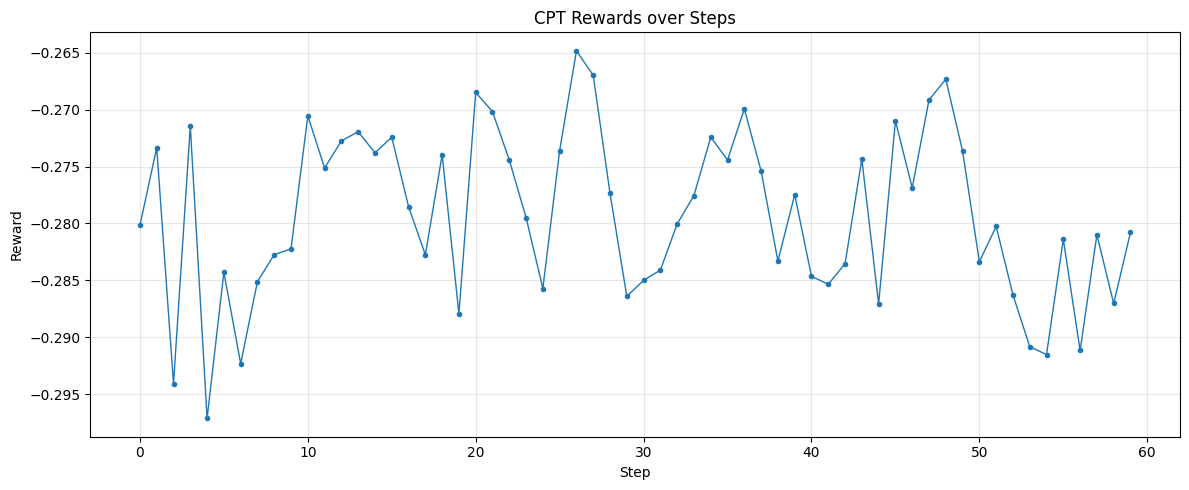

Total reward: -16.76
Average reward per step: -0.28


In [ ]:
if __name__ == '__main__':
    
    env = CPTPrefetchEnvSimple(
        num_tiles=num_tiles,
        n_users=n_users,
        cache_capacity=50,
        user_tiles=user_tiles,
        videos_requests=videos_requests_idx 
    )

    obs = env.reset()
    done = False

    total_reward, rewards_list = 0.0, []
    for step in range(60):
        # action = map_user_tiles_to_action(obs, step)
        actions = [
            { 
                'user': i,
                'video': videos_requests_idx[i],
                'tiles': tiles_to_action_mapping(obs, step, i) 
            } for i in range(n_users)
        ]
        
        obs, reward, done, info = env.step(actions)
        total_reward += reward
        rewards_list.append(reward)

        print(f"Obs: {obs}, Reward: {reward}, Done: {done}")

    print(f"Total reward: {total_reward}")

    import matplotlib.pyplot as plt
    # Plot rewards over steps
    plt.figure(figsize=(12, 5))
    plt.plot(range(60), rewards_list, marker='o', linestyle='-', linewidth=1, markersize=3)
    plt.xlabel('Step')
    plt.ylabel('Reward')
    plt.title('CPT Rewards over Steps')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Total reward: {sum(rewards_list):.2f}")
    print(f"Average reward per step: {np.mean(rewards_list):.2f}")

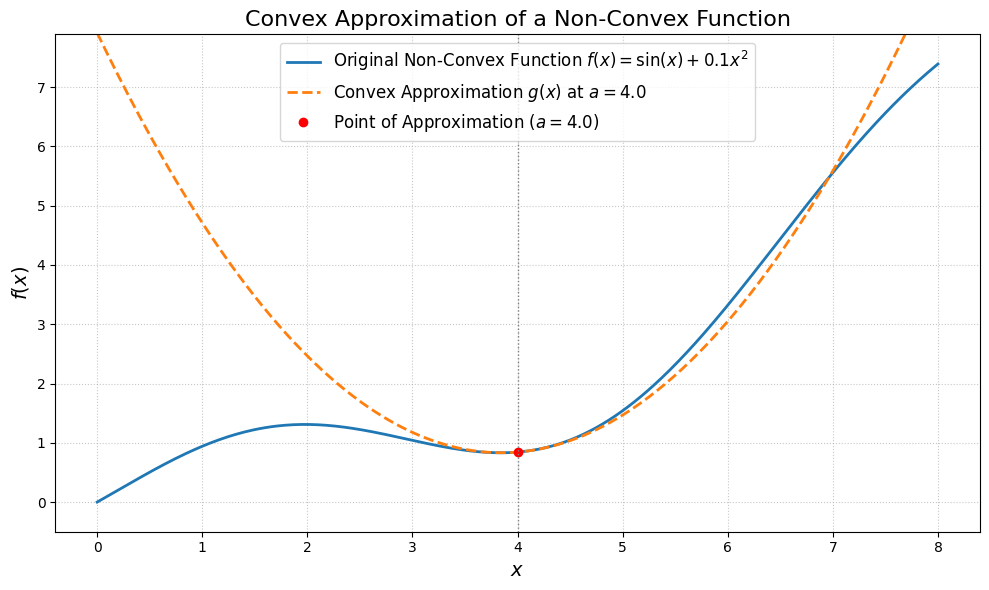

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Define the original non-convex function
def f(x):
    return np.sin(x) + 0.1 * x**2

# Define the first derivative
def f_prime(x):
    return np.cos(x) + 0.2 * x

# Define the second derivative
def f_double_prime(x):
    return -np.sin(x) + 0.2

# Set the point of approximation
a = 4.0

# Get values at point 'a'
f_a = f(a)
fp_a = f_prime(a)
fpp_a = f_double_prime(a)

# Define the second-order Taylor (quadratic) approximation
# This is a convex parabola because f_double_prime(a) is positive
def g(x):
    return f_a + fp_a * (x - a) + 0.5 * fpp_a * (x - a)**2

# Generate x values for plotting
x = np.linspace(0, 8, 400)
y_f = f(x)
y_g = g(x)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, y_f, label='Original Non-Convex Function $f(x) = \\sin(x) + 0.1x^2$', linewidth=2)
plt.plot(x, y_g, label=f'Convex Approximation $g(x)$ at $a={a}$', linestyle='--', linewidth=2)

# Mark the point of approximation
plt.plot(a, f_a, 'ro', label=f'Point of Approximation ($a={a}$)')

# Add labels, title, legend, and grid
plt.title('Convex Approximation of a Non-Convex Function', fontsize=16)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$f(x)$', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# Set y-limits to better see the approximation
plt.ylim(min(y_f) - 0.5, max(y_f) + 0.5)

# Add a vertical line to show the approximation point
plt.axvline(x=a, color='gray', linestyle=':', linewidth=1)

plt.tight_layout()
# Save the plot
plt.show()

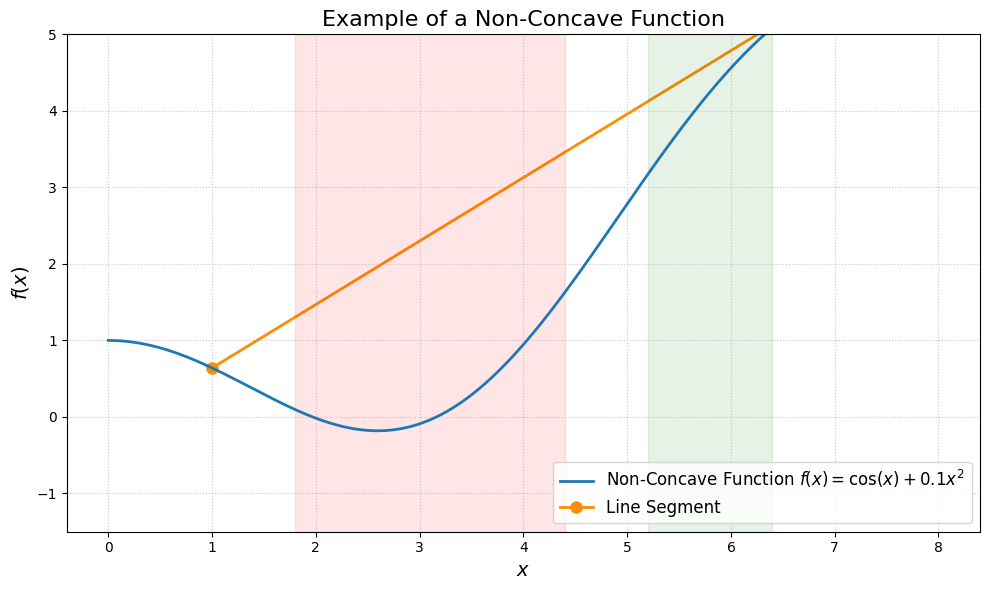

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Define the original non-convex, non-concave function
def f(x):
    return np.cos(x) + 0.1 * x**2

# Generate x values for plotting
x = np.linspace(0, 8, 400)
y_f = f(x)

# Define the two points for the secant line
x1, x2 = 1.0, 6.5
y1, y2 = f(x1), f(x2)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, y_f, label='Non-Concave Function $f(x) = \\cos(x) + 0.1x^2$', linewidth=2, zorder=2)

# Plot the line segment (secant line)
plt.plot([x1, x2], [y1, y2], 'o-', label='Line Segment', color='darkorange', linewidth=2, markersize=8, zorder=1)

# Add labels, title, legend, and grid
plt.title('Example of a Non-Concave Function', fontsize=16)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$f(x)$', fontsize=14)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

# Highlight regions
plt.axvspan(1.8, 4.4, color='red', alpha=0.1, label='Line segment is ABOVE graph')
plt.axvspan(5.2, 6.4, color='green', alpha=0.1, label='Line segment is BELOW graph')

plt.ylim(-1.5, 5)
plt.tight_layout()

# Save the plot
plt.show()

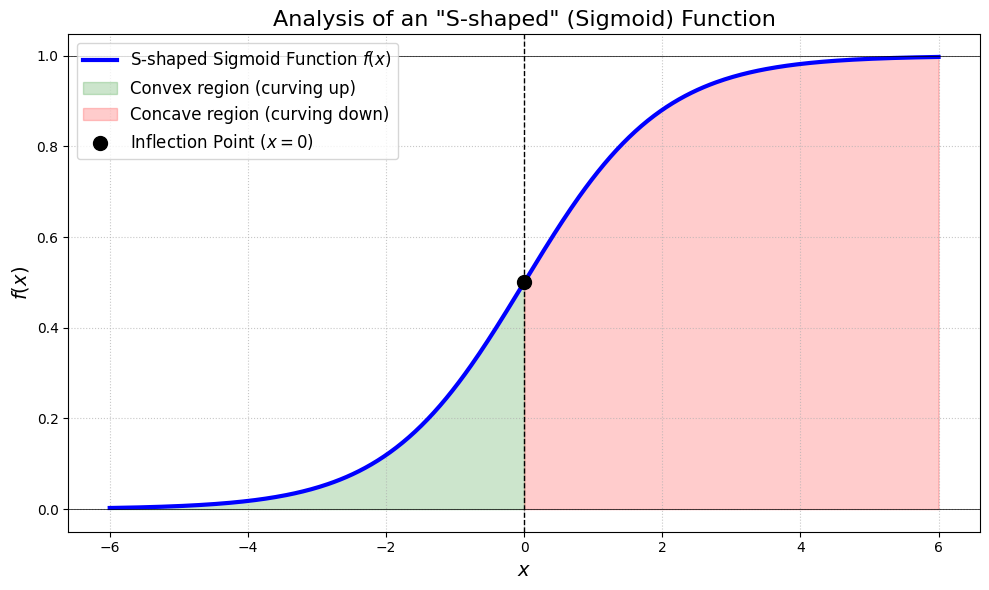

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Define the logistic (sigmoid) function
def f(x):
    return 1 / (1 + np.exp(-x))

# Generate x values for plotting
x = np.linspace(-6, 6, 400)
y_f = f(x)

# The inflection point is at x=0 for this function
inflection_point_x = 0
inflection_point_y = f(inflection_point_x)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, y_f, label='S-shaped Sigmoid Function $f(x)$', linewidth=3, color='blue')

# Highlight the convex part (x < 0)
x_convex = np.linspace(-6, 0, 200)
y_convex = f(x_convex)
plt.fill_between(x_convex, y_convex, 0, color='green', alpha=0.2, label='Convex region (curving up)')

# Highlight the concave part (x > 0)
x_concave = np.linspace(0, 6, 200)
y_concave = f(x_concave)
plt.fill_between(x_concave, y_concave, 0, color='red', alpha=0.2, label='Concave region (curving down)')

# Mark the inflection point
plt.plot(inflection_point_x, inflection_point_y, 'ko', markersize=10, label=f'Inflection Point ($x={inflection_point_x}$)')

# Add labels, title, legend, and grid
plt.title('Analysis of an "S-shaped" (Sigmoid) Function', fontsize=16)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$f(x)$', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

plt.axhline(y=0, color='black', linewidth=0.5)
plt.axhline(y=1, color='black', linewidth=0.5)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
# Save the plot
plt.savefig('s_shape_function.png')

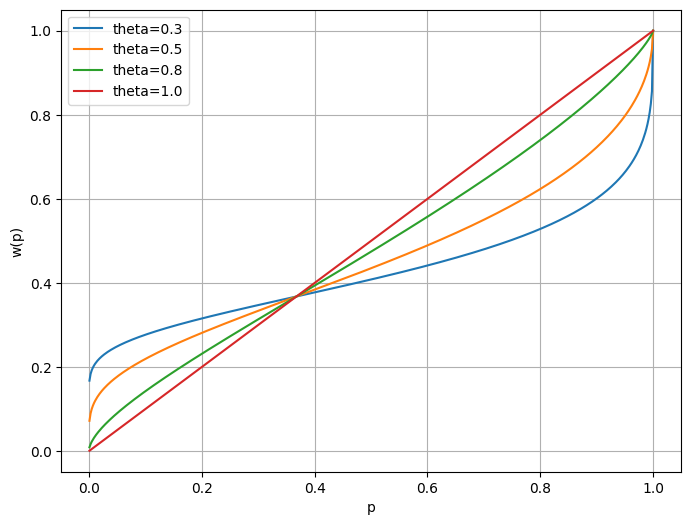

In [49]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.001, 1, 500)

def prelec_weight(p, alpha):
    return np.exp(-((-np.log(p)) ** alpha))

alphas = [0.3, 0.5, 0.8, 1.0]

plt.figure(figsize=(8,6))
for a in alphas:
    plt.plot(p, prelec_weight(p, a), label=f'theta={a}')

plt.xlabel("p")
plt.ylabel("w(p)")
plt.legend()
plt.grid(True)

plt.show()